In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("../data/ai_job_dataset.csv")
data.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


Salary-requiredskills
Job title-requiredskills
Salary-yearsexperience

# Quantitative - Quantitative

In [4]:
def quantiQuati(i, j, data):
    var1, var2 = data[i], data[j]
    print(f"c'est entre {i} et {j}")
    fig, axes = plt.subplots(2, 2, figsize=(12, 14))
    fig.suptitle(f"{i}  ×  {j}", fontsize=16, fontweight="bold", y=1.01)

    # Scatter plot
    sns.scatterplot(x=var1, y=var2, data=data, ax=axes[0, 0])
    axes[0, 0].set_title("Scatter plot")

    # Régression , diagramme en points
    sns.regplot(x=var1, y=var2, data=data, ax=axes[0, 1])
    axes[0, 1].set_title("Régression")

    # Hexbin
    hb = axes[1, 0].hexbin(var1, var2, gridsize=30, cmap="Blues")
    fig.colorbar(hb, ax=axes[1, 0])
    axes[1, 0].set_title("Hexbin")
    axes[1, 0].set_xlabel(i)
    axes[1, 0].set_ylabel(j)

    axes[1, 1].set_visible(False)

    plt.tight_layout()
    plt.show()
    print("─" * 80)
    print("*"*100)


c'est entre years_experience et salary_usd


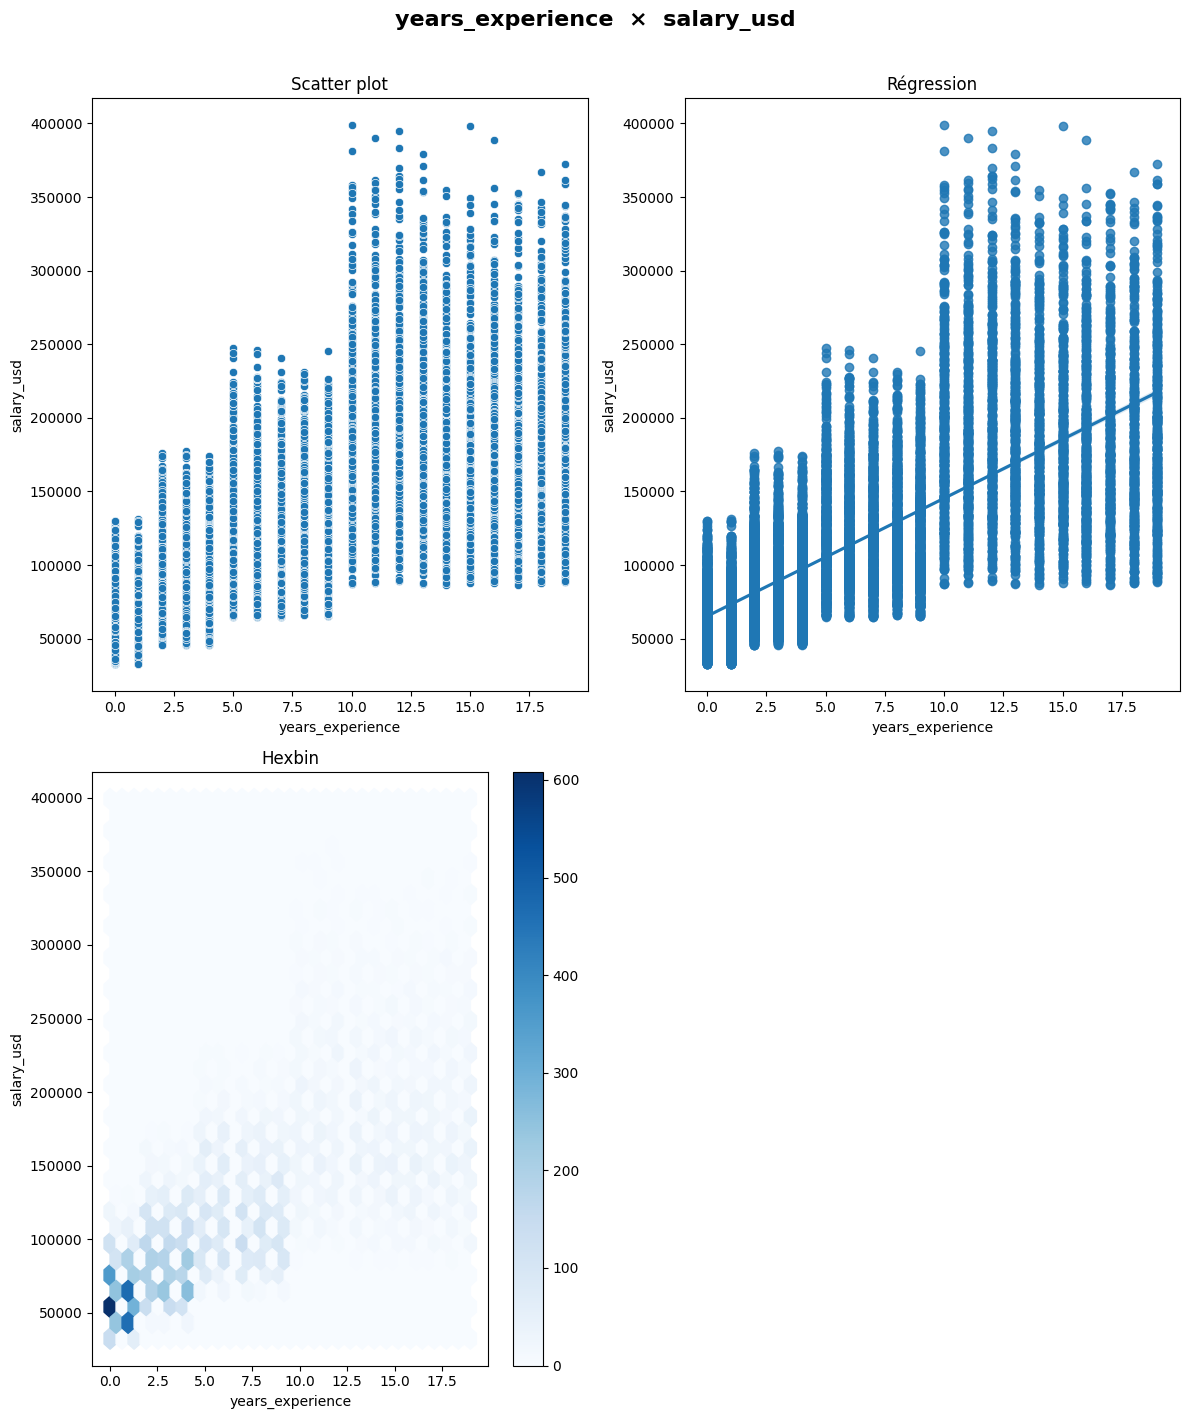

────────────────────────────────────────────────────────────────────────────────
****************************************************************************************************


In [5]:
quantiQuati('years_experience','salary_usd',data=data)

# Qualitative - Quantitative

In [6]:
# Séparer les skills et dupliquer les lignes
data = data.assign(required_skills=data["required_skills"].str.split(",")).explode("required_skills")
data["required_skills"] = data["required_skills"].str.strip()

def qualiQuati(i, j, data, top_n=15):
    print(f"c'est entre {i} et {j}")
    top_cats = data[i].value_counts().nlargest(top_n).index
    df = data[data[i].isin(top_cats)]
    
    var1, var2 = df[i], df[j]

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f"{i}  ×  {j}  (top {top_n})", fontsize=16, fontweight="bold", y=1.01)

    # Boxplot
    sns.boxplot(x=var1, y=var2, data=df, ax=axes[0, 0])
    axes[0, 0].set_title("Boxplot")
    axes[0, 0].tick_params(axis="x", rotation=90)

    # Violin plot
    sns.violinplot(x=var1, y=var2, data=df, ax=axes[0, 1])
    axes[0, 1].set_title("Violin plot")
    axes[0, 1].tick_params(axis="x", rotation=90)

    # Strip plot
    sns.stripplot(x=var1, y=var2, data=df, ax=axes[1, 0], alpha=0.3, size=3)
    axes[1, 0].set_title("Strip plot")
    axes[1, 0].tick_params(axis="x", rotation=90)

    # Strip plot densité
    sns.stripplot(x=var1, y=var2, data=df, ax=axes[1, 1], alpha=0.3, size=3)
    axes[1, 1].set_title("Strip plot (densité)")
    axes[1, 1].tick_params(axis="x", rotation=90)

    # Bar chart
    sns.barplot(x=var1, y=var2, data=df, ax=axes[2, 0], estimator=np.mean)
    axes[2, 0].set_title("Bar chart (moyenne)")
    axes[2, 0].tick_params(axis="x", rotation=90)

    axes[2, 1].set_visible(False)

    plt.tight_layout()
    plt.show()
    print("─" * 80)

c'est entre required_skills et salary_usd


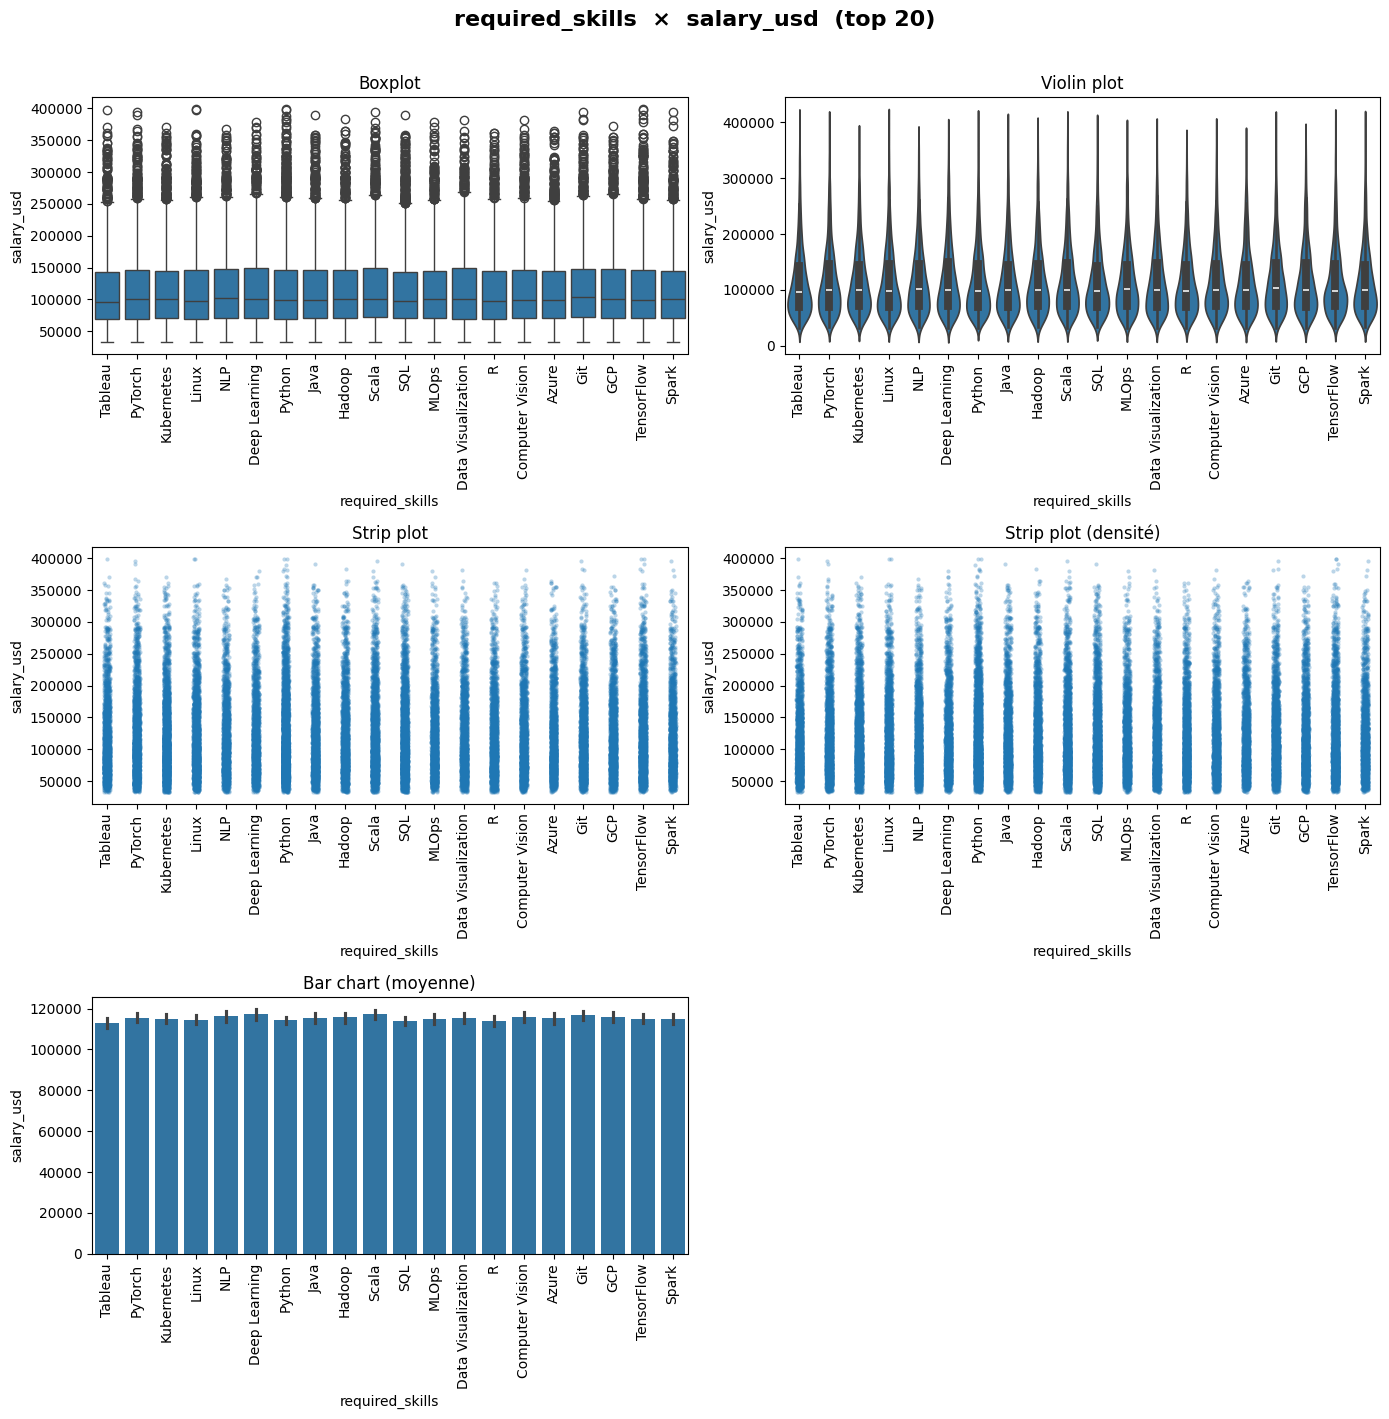

────────────────────────────────────────────────────────────────────────────────


In [7]:
qualiQuati("required_skills", "salary_usd", data, top_n=20)

# Qualitative - Qualitative

In [9]:
!pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.6 MB 2.8 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.6 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.6 MB 2.7 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.6 MB 2.8 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 2.8 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 2.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 2.6 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.6 MB 2.6 MB/s eta 0:00:02
   --------------------------- -----


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from statsmodels.graphics.mosaicplot import mosaic

def quali2(i, j, data, top_n=15):
    top_i = data[i].value_counts().nlargest(top_n).index
    top_j = data[j].value_counts().nlargest(top_n).index
    df = data[data[i].isin(top_i) & data[j].isin(top_j)]

    var1, var2 = df[i], df[j]
    table = pd.crosstab(var1, var2)

    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    fig.suptitle(f"{i}  ×  {j}  (top {top_n})", fontsize=16, fontweight="bold", y=1.01)

    # Count plot simple
    sns.countplot(x=var1, data=df, ax=axes[0, 0])
    axes[0, 0].set_title("Count plot")
    axes[0, 0].tick_params(axis="x", rotation=90)

    # Barres croisées
    table.plot(kind="bar", ax=axes[0, 1])
    axes[0, 1].set_title("Barres croisées")
    axes[0, 1].tick_params(axis="x", rotation=90)

    # Barres empilées
    table.plot(kind="bar", stacked=True, ax=axes[1, 0])
    axes[1, 0].set_title("Barres empilées")
    axes[1, 0].tick_params(axis="x", rotation=90)

    # Heatmap
    annot = table.shape[0] * table.shape[1] <= 100
    sns.heatmap(table, annot=annot, fmt="d", cmap="Blues", ax=axes[1, 1])
    axes[1, 1].set_title("Tableau de contingence")

    # Mosaic plot
    mosaic_data = df[[i, j]].copy()
    mosaic(
        mosaic_data,
        [i, j],
        ax=axes[2, 0],
        title="Mosaic plot",
        gap=0.02,
        labelizer=lambda k: "",   
    )
    axes[2, 0].tick_params(axis="x", rotation=90)

    axes[2, 1].set_visible(False)

    plt.tight_layout()
    plt.show()
    print("─" * 80)

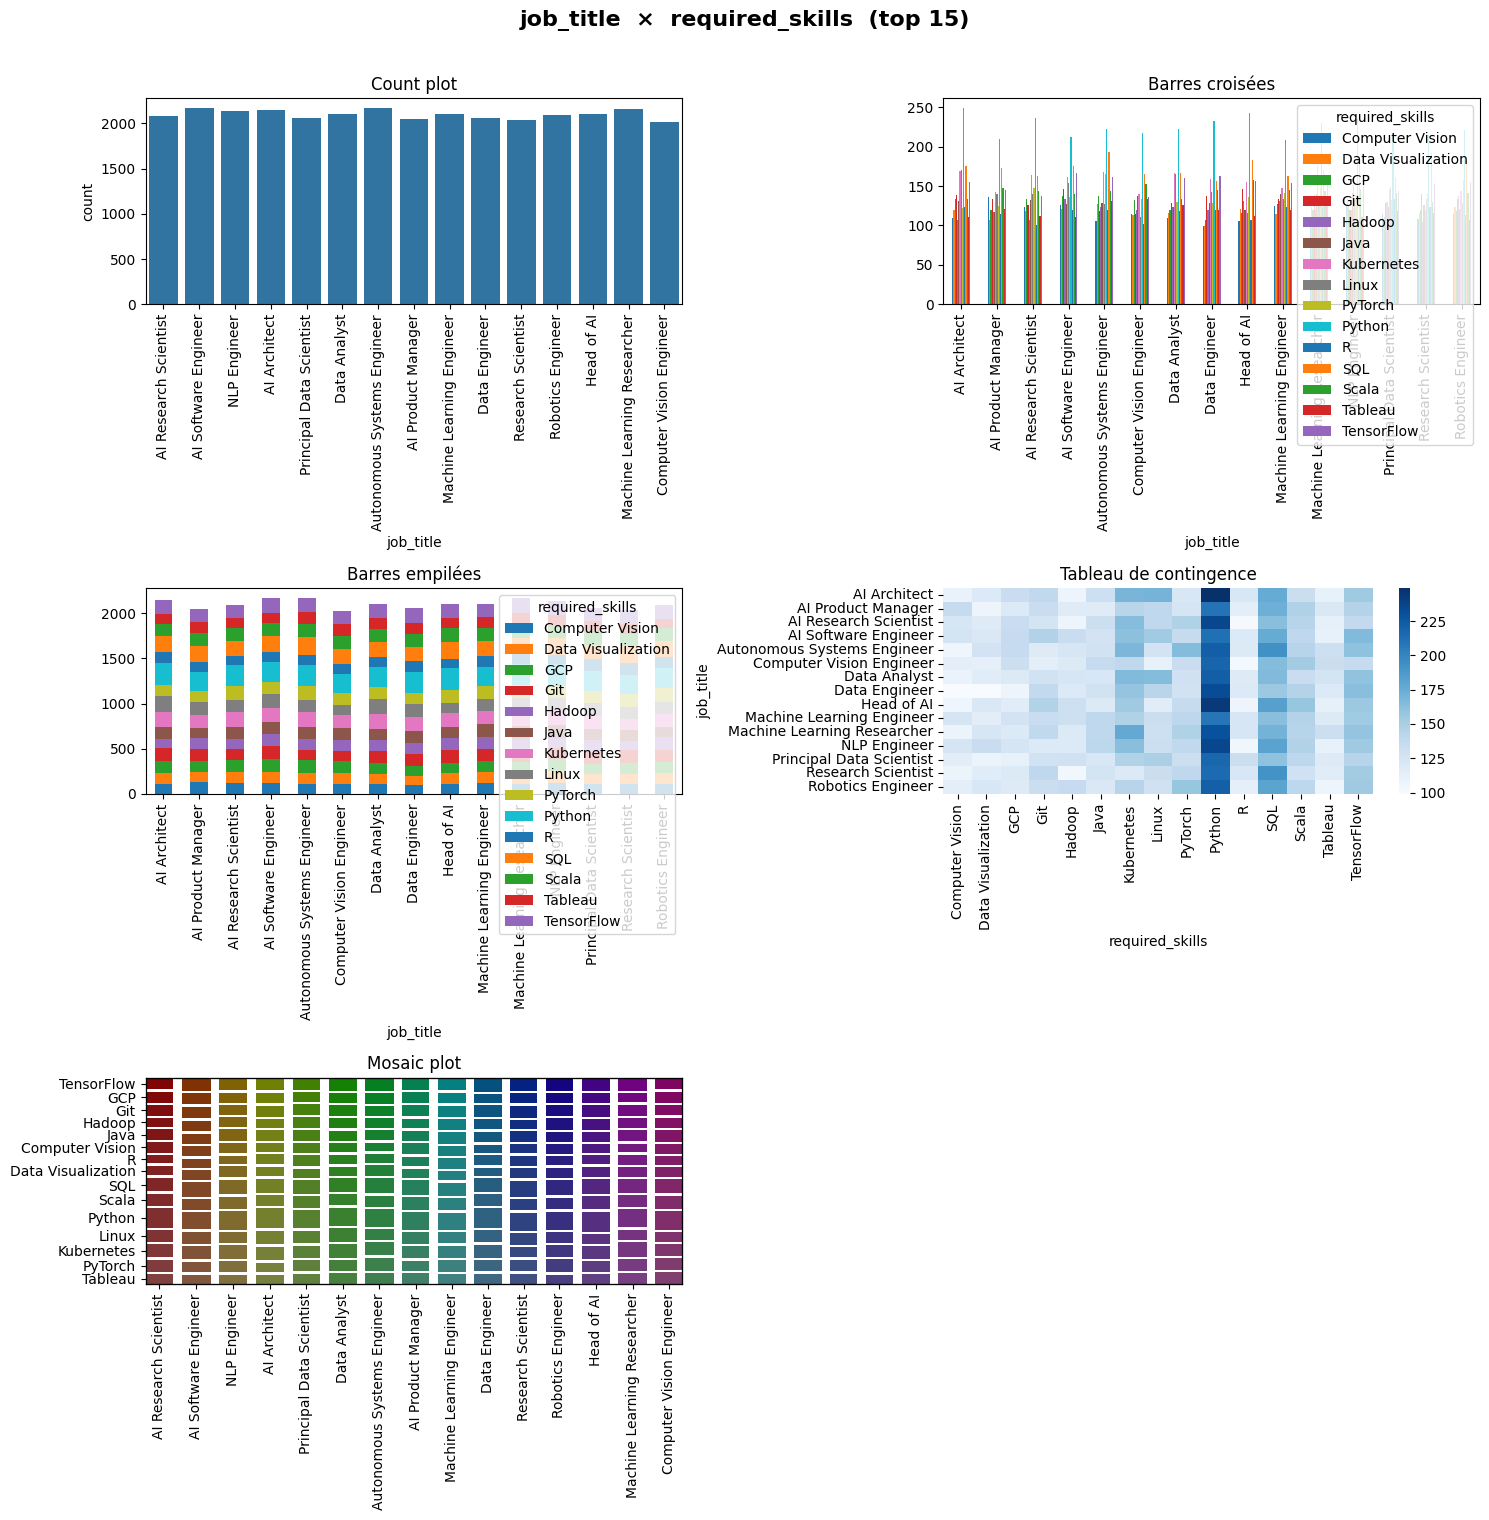

────────────────────────────────────────────────────────────────────────────────


In [12]:
quali2('job_title','required_skills',data=data,top_n=15)